## ReLU MLP Single-Seed Learning Dynamics

This notebook runs a standard fully connected ReLU network with a single training phase.

It focuses on one seed to inspect learning dynamics clearly (checkpoints, scatter alignment, and start/end metrics).

No dropout, normalization, or multi-phase logic is used.

In [1]:
from pathlib import Path

from itables import show
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from layer_lenses.odt import samples_reaching_node
from layer_lenses.odt import odt_leaf_ids_for_x
from layer_lenses.relu_analysis import (
    collect_start_end_metrics,
    first_layer_odt_alignment,
    masked_accuracy_by_odt_leaf,
    neuron_leaf_responsibility_from_ablation,
    plot_first_layer_odt_alignment,
    plot_layered_relu_graph,
    quadratic_snapshot_epochs,
    run_single_relu_seed,
    summarize_neuron_responsibility,
)
from layer_lenses.relu_analysis import log_loss_gradients
from layer_lenses.relu_training import checkpoint_model_from_state
from layer_lenses.relu_analysis import activation_tensor_by_layer_neuron_data

from pathlib import Path
import pickle
from typing import Any

def save_seed_result_pickle(seed_result: dict[str, Any], path: str | Path) -> Path:
    """Save seed_result to a pickle file."""
    out_path = Path(path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("wb") as f:
        pickle.dump(seed_result, f, protocol=pickle.HIGHEST_PROTOCOL)
    return out_path


def load_seed_result_pickle(path: str | Path) -> dict[str, Any]:
    """Load seed_result from a pickle file."""
    in_path = Path(path)
    with in_path.open("rb") as f:
        obj = pickle.load(f)
    if not isinstance(obj, dict):
        raise TypeError(f"Expected dict from pickle, got {type(obj).__name__}")
    return obj


In [2]:


# Scratch-aligned defaults with a plain ReLU MLP.
DIM = 100
DEPTH = 5
N_TRAIN = 80_000
HIDDEN_DIMS = [80, 80]

TOTAL_EPOCHS = 2000
LR = 2e-3
BATCH_SIZE = 80
WEIGHT_DECAY = 0.01

SNAPSHOT_EPOCHS = range(TOTAL_EPOCHS)
print(f"Using {len(SNAPSHOT_EPOCHS)} snapshot epochs.")

SEED = 5178

seed_result = None

Using 2000 snapshot epochs.


## Run selected seed

This is the expensive cell. It runs single-phase ReLU MLP training for the selected seed.

In [ ]:
print(f"Running seed {SEED} ...")
seed_result = run_single_relu_seed(
    SEED,
    dim=DIM,
    depth=DEPTH,
    n_train=N_TRAIN,
    hidden_dims=HIDDEN_DIMS,
    total_epochs=TOTAL_EPOCHS,
    lr=LR,
    batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    snapshot_epochs=SNAPSHOT_EPOCHS,
    project_first_layer_grad_orthogonal=None,
    odt_hyperplanes = "coordinate_axes",
    
)
print("Done")

Running seed 5178 ...


Training ReLU MLP:   0%|          | 0/2001 [00:00<?, ?it/s]

Done


In [ ]:

# Save
# save_path = save_seed_result_pickle(seed_result, "results/cache/seed_result_5178_2hidden_80_80.pkl")
# print("Saved to:", save_path)

## Load
# seed_result = load_seed_result_pickle("results/cache/seed_result_5178.pkl")
# print(seed_result.keys())

dict_keys(['master_seed', 'seeds', 'tree', 'meta', 'data', 'out'])


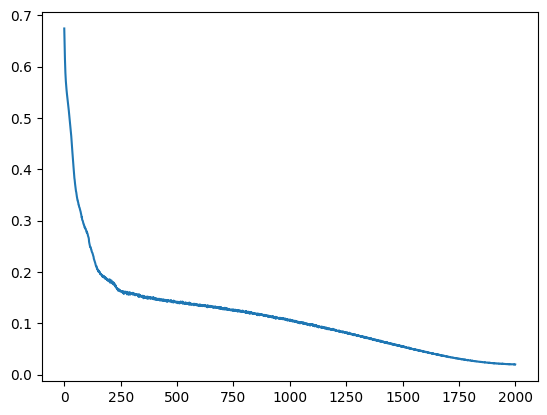

In [4]:
plt.plot(seed_result["out"]["epoch_losses"])

## Scatter plot and gating dynamics analysis

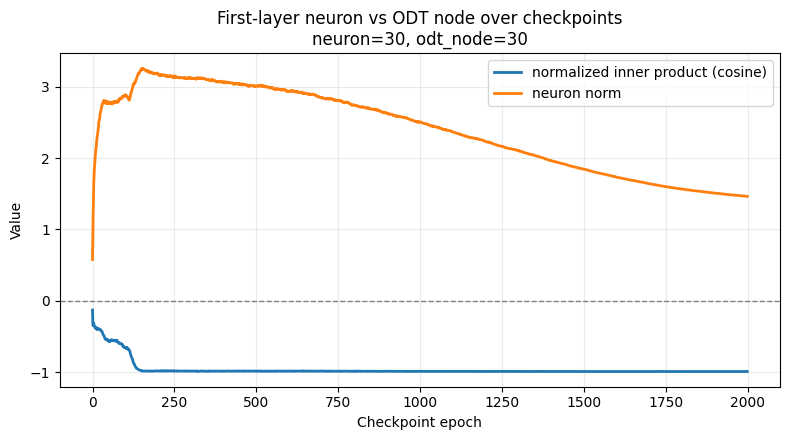

In [224]:
# Track checkpoint-wise cosine similarity and neuron norm for one first-layer neuron and one ODT internal node.
FIRST_LAYER_NEURON_ID = 30
ODT_INTERNAL_NODE_ID = 30
NUM_POINTS_PLOT = 1999

out = seed_result["out"]
ckpts = out["checkpoint_snapshots"]
tree = seed_result["tree"]

internal_node_count = seed_result["tree"].w_list.shape[0]
if not (0 <= FIRST_LAYER_NEURON_ID < ckpts[0]["hidden_layers.0.weight"].shape[0]):
    raise ValueError(
        f"FIRST_LAYER_NEURON_ID must be in [0, {ckpts[0]['hidden_layers.0.weight'].shape[0]-1}], "
        f"got {FIRST_LAYER_NEURON_ID}."
    )
if not (0 <= ODT_INTERNAL_NODE_ID < internal_node_count):
    raise ValueError(
        f"ODT_INTERNAL_NODE_ID must be in [0, {internal_node_count-1}], got {ODT_INTERNAL_NODE_ID}."
    )

epochs = sorted(ckpts.keys())[:NUM_POINTS_PLOT]
odt_vec = torch.from_numpy(seed_result["tree"].w_list[ODT_INTERNAL_NODE_ID]).float()
odt_norm = float(torch.norm(odt_vec).clamp_min(1e-12))

normalized_inner_products = []
neuron_norms = []

for ep in epochs:
    w = ckpts[ep]["hidden_layers.0.weight"][FIRST_LAYER_NEURON_ID].detach().cpu().float()
    w_norm = float(torch.norm(w).clamp_min(1e-12))
    cosine = float(torch.dot(w, odt_vec) / (w_norm * odt_norm))

    normalized_inner_products.append(cosine)
    neuron_norms.append(w_norm)

plt.figure(figsize=(8, 4.5))
plt.plot(
    epochs,
    normalized_inner_products,
    # marker=".",
    linewidth=2.,
    label="normalized inner product (cosine)",
)
plt.plot(
    epochs,
    neuron_norms,
    # marker=".",
    linewidth=2.,
    label="neuron norm",
)
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Checkpoint epoch")
plt.ylabel("Value")
plt.title(
    "First-layer neuron vs ODT node over checkpoints\n"
    f"neuron={FIRST_LAYER_NEURON_ID}, odt_node={ODT_INTERNAL_NODE_ID}"
)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

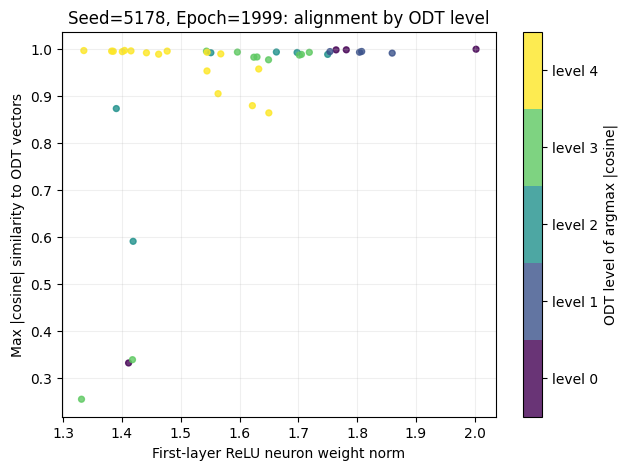

In [225]:
EPOCH = list(ckpts.keys())[1999]  # choose from available checkpoints

alignment, fig, ax = plot_first_layer_odt_alignment(
    state_dict=ckpts[EPOCH],
    tree=tree,
    depth=DEPTH,
    epoch=EPOCH,
    seed=SEED,
)
plt.show()

# Keep these names available for downstream scratch cells.
first_layer_wts = alignment["first_layer_wts"]
odt_wts = alignment["odt_wts"]
row_norms = alignment["row_norms"]
cos = alignment["cos"]
abs_cos = alignment["abs_cos"]
max_abs_cos = alignment["max_abs_cos"]
closest_odt = alignment["closest_odt"]
closest_odt_np = alignment["closest_odt_np"]
node_level = alignment["node_level"]

## Load neural net parameters from given epoch into W0, W1, W2 and Wout

In [226]:
# Layered ReLU graph at a chosen snapshot epoch.
GRAPH_EPOCH = EPOCH
ALIGNMENT_ABS_THRESHOLD = 0.8
EDGE_ABS_THRESHOLD = 0.020  # tune this; increase if graph is too dense
FIGSIZE = (14, 18)
NODE_MASK = np.zeros((40, 3), dtype=bool)
NODE_MASK[:, 0] = True
NODE_MASK[7, 1] = True
NODE_MASK[:, 2] = True

state = ckpts[GRAPH_EPOCH]
W0 = state["hidden_layers.0.weight"].detach().cpu()
W1 = state["hidden_layers.1.weight"].detach().cpu()
W2 = state["hidden_layers.2.weight"].detach().cpu()
Wout = state["output_layer.weight"].detach().cpu()


In [227]:
# max_w,argmax_w=torch.max(W0.abs(), dim=0)
# for j in range(32):
#     print(j,max_w[j],W0[argmax_w[j]].norm())



## Visualise neural net as graph

Visible edges: 103 / 3240
First-layer aligned nodes: 36 / 40


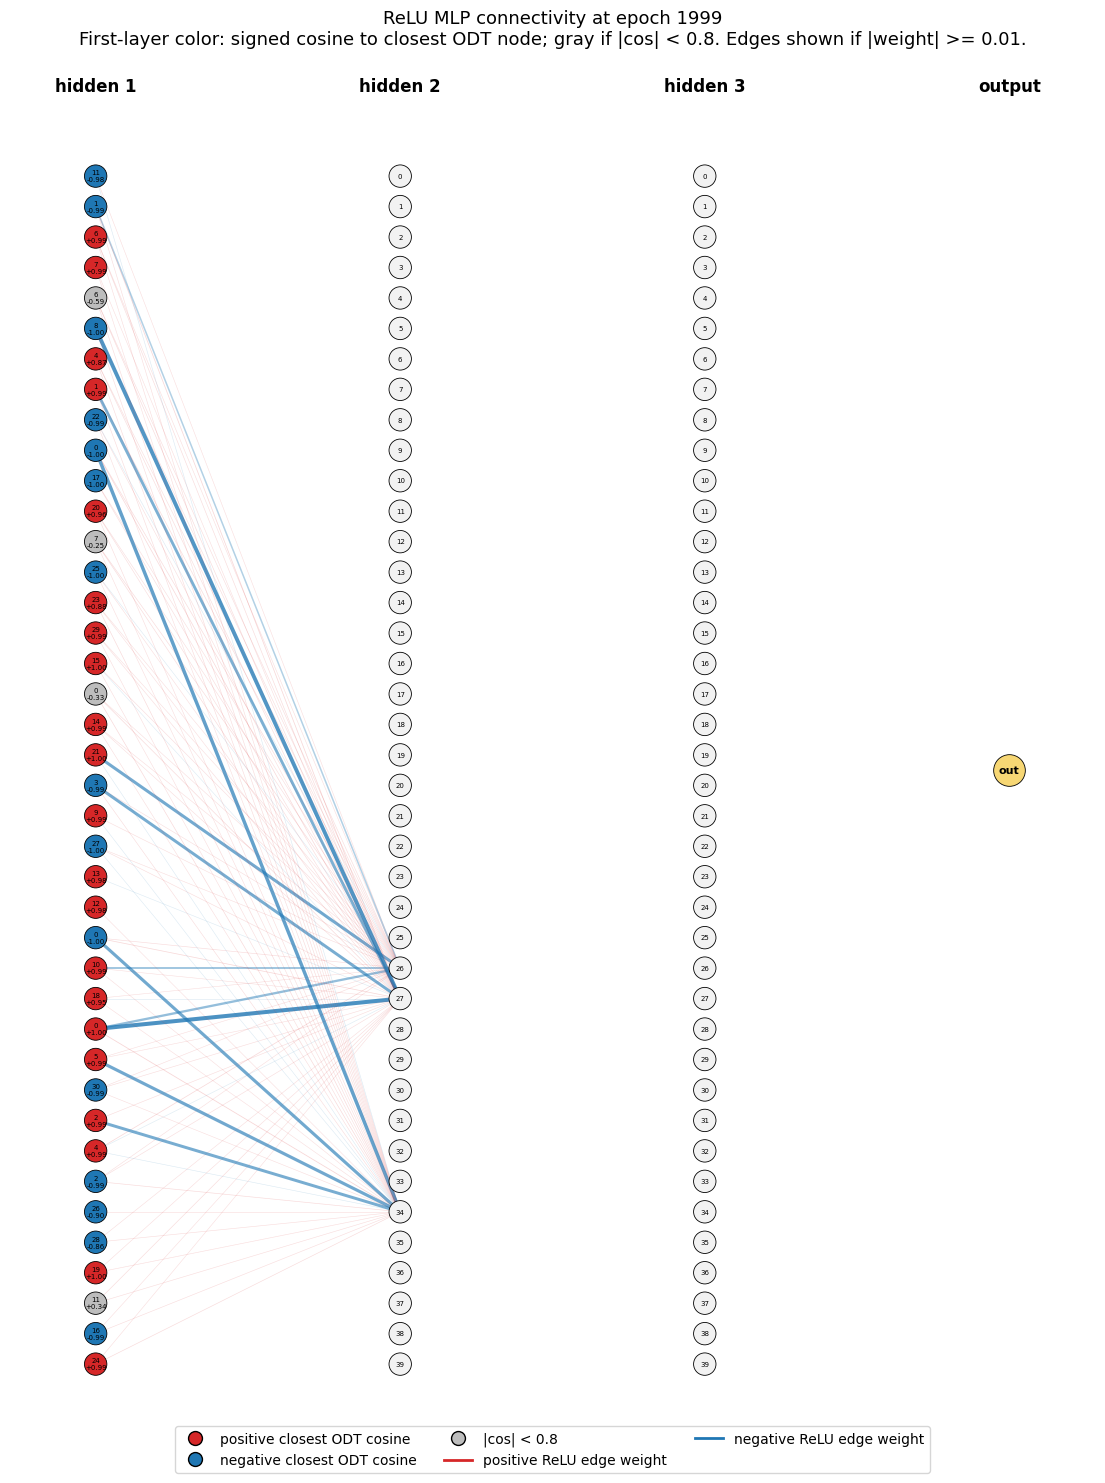

In [330]:


# Layered ReLU graph at a chosen snapshot epoch.
ALIGNMENT_ABS_THRESHOLD = 0.8
EDGE_ABS_THRESHOLD = 0.01  # tune this; increase if graph is too dense
FIGSIZE = (14, 18)
NODE_MASK = np.zeros((40, 3), dtype=bool)
NODE_MASK[:, 0] = True
NODE_MASK[26, 1] = True
NODE_MASK[27, 1] = True
NODE_MASK[34, 1] = True
# NODE_MASK[:, 2] = True

state = ckpts[GRAPH_EPOCH]
W0 = state["hidden_layers.0.weight"].detach().cpu()
W1 = state["hidden_layers.1.weight"].detach().cpu()
W2 = state["hidden_layers.2.weight"].detach().cpu()
Wout = state["output_layer.weight"].detach().cpu()

graph_alignment, visible_edges, graph_fig, graph_ax = plot_layered_relu_graph(
    state_dict=state,
    tree=tree,
    depth=DEPTH,
    epoch=GRAPH_EPOCH,
    node_mask=NODE_MASK,
    alignment_abs_threshold=ALIGNMENT_ABS_THRESHOLD,
    edge_abs_threshold=EDGE_ABS_THRESHOLD,
    figsize=FIGSIZE,
    require_both_edge_endpoints_selected=True,
)
plt.show()

## Computing neuron responsibilities -- i.e. log loss changes to data entering leaf nodes on neuron removal

In [27]:
checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])
base_node_mask = np.ones((80, 2), dtype=int)

neuron_responsibility, neuron_responsibility_df, baseline_leaf_metrics = (
    neuron_leaf_responsibility_from_ablation(
        model=checkpoint_model,
        x_eval=seed_result["data"]["x_eval"],
        y_eval=seed_result["data"]["y_eval"],
        tree=seed_result["tree"],
        base_node_mask=base_node_mask,
        min_log_loss_delta=0.1,
        min_relative_log_loss_delta=None,
        min_accuracy_drop=None,
    )
)
neuron_summary = summarize_neuron_responsibility(neuron_responsibility)


In [28]:

show(
    neuron_summary,
    scrollY="500px",
    scrollX=True,
    search=True,
    paging=True,
    pageLength=32,
)

Loading ITables v2.7.3 from the internet... (need help?)


In [60]:
checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])

# Shape (40, 3): 1 keeps a hidden node, 0 masks it out.
node_mask = np.ones((40, 3), dtype=int)
node_mask[:, 1] = 0
node_mask[7, 1] = 1
# second hidden layer neuron : ODT node responsibilities
# 0: [49], 4: [46], 5: [50,51,52,53,54], 6: [39], 7:[62], 9:[36], 10 : [55, 56, 57, 58]

leaf_accuracy = masked_accuracy_by_odt_leaf(
    model=checkpoint_model,
    node_mask=node_mask,
    x_eval=seed_result["data"]["x_eval"],
    y_eval=seed_result["data"]["y_eval"],
    tree=seed_result["tree"],
)

display(leaf_accuracy)
print("Overall masked accuracy:", np.average(leaf_accuracy["accuracy"], weights=leaf_accuracy["num_samples"]))

,leaf_node,leaf_index,true_label,num_samples,num_correct,accuracy,mean_log_loss,mean_logit,mean_abs_logit
0,31,0,-1,2551,1835,0.719326,0.340681,-1.529980,1.529980
1,32,1,1,2521,1100,0.436335,1.440169,-1.000382,1.000382
2,33,2,-1,2516,2002,0.795707,0.271269,-2.003748,2.003748
3,34,3,1,2458,1057,0.430024,1.436428,-0.999349,0.999349
4,35,4,-1,2417,1834,0.758792,0.298219,-1.857386,1.857387
5,36,5,1,2602,1082,0.415834,1.641526,-1.228962,1.228962
6,37,6,-1,2516,1629,0.647456,0.374785,-1.399009,1.399009
7,38,7,1,2519,834,0.331084,1.797082,-1.433291,1.433291
8,39,8,-1,2541,1989,0.782763,0.278401,-1.974814,1.974814
9,40,9,1,2474,809,0.327001,1.789939,-1.428916,1.428916


Overall masked accuracy: 0.5355


## Neuron activity breakdown -- neuron activity based on data entering ODT leaf nodes 

In [11]:

checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])

acts = activation_tensor_by_layer_neuron_data(
    model=checkpoint_model,
    x_eval=seed_result["data"]["x_eval"],
)
outputs = checkpoint_model(torch.tensor(seed_result["data"]["x_eval"], dtype=torch.float32)).detach().cpu().numpy()
labels = seed_result["data"]["y_eval"]

residues = np.exp(-labels*outputs)/(1+np.exp(-labels*outputs))
leaf_ids = odt_leaf_ids_for_x(seed_result["data"]["x_eval"], seed_result["tree"])

print("activation_tensor shape:", acts.shape)  # (layers, neurons, num_data)



activation_tensor shape: (3, 40, 80000)


In [12]:

np.histogram(leaf_ids[acts[2,0]], bins=np.arange(31,64))

(array([  39,  221,   66,  120,   41,  190,  680,  683, 2444, 2006, 2328,
        1863, 1474, 1781,  181, 1631, 2457, 2048, 2420, 2056, 1150, 1017,
        1628,  808, 2424,  776, 2433, 2507, 2401, 2378, 2239, 2454]),
 array([31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
        48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]))

In [241]:
i1=30

state = ckpts[EPOCH]
W0 = state["hidden_layers.0.weight"].detach().cpu()
W1 = state["hidden_layers.1.weight"].detach().cpu()
W2 = state["hidden_layers.2.weight"].detach().cpu()
Wout = state["output_layer.weight"].detach().cpu()
checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])
acts = activation_tensor_by_layer_neuron_data( model=checkpoint_model, x_eval=seed_result["data"]["x_eval"])
total_lens = np.zeros(acts.shape[2])
i1=30
for i2 in range(40):
    for i3 in range(40):
        curr_active = acts[0,i1]*acts[1,i2]*acts[2,i3]
        curr_val = W1[i2,i1]*W2[i3,i2]*Wout[0,i3]
        curr_val = curr_val.detach().cpu().numpy()
        weighted_curr_lens = curr_active*curr_val
        total_lens += weighted_curr_lens

total_lens *= residues * -1 * labels
grad_alt = total_lens @ seed_result["data"]["x_eval"]/len(residues) # this should correspond to the gradient of the log loss with respect to the neuron i1 in hidden layer 1


grad_check = log_loss_gradients(
    model=checkpoint_model,
    x=seed_result["data"]["x_eval"],
    y=seed_result["data"]["y_eval"],
)
true_grad = grad_check["hidden_layers.0.weight"][i1].numpy()


In [ ]:


from tqdm.std import tqdm

for curr_layer2_node in range(40):
    i1=30
    true_grad_dict = {}
    grad_alt_dict = {}
    W0_dict = {}
    for epoch in tqdm(range(1900,2000)):
        state = ckpts[epoch]
        W0 = state["hidden_layers.0.weight"].detach().cpu()
        W1 = state["hidden_layers.1.weight"].detach().cpu()
        W2 = state["hidden_layers.2.weight"].detach().cpu()
        Wout = state["output_layer.weight"].detach().cpu()
        checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], state)
        outputs = checkpoint_model(torch.tensor(seed_result["data"]["x_eval"], dtype=torch.float32)).detach().cpu().numpy()
        labels = seed_result["data"]["y_eval"]
        residues = np.exp(-labels*outputs)/(1+np.exp(-labels*outputs))
        residues = (residues+1000.)/2000 #making residues approx. equal to 0.5

        acts = activation_tensor_by_layer_neuron_data( model=checkpoint_model, x_eval=seed_result["data"]["x_eval"])
        total_lens = np.zeros(acts.shape[2])
        for i2 in range(40):
            if i2 != curr_layer2_node:
                continue
            for i3 in range(40):
                curr_active = acts[0,i1]*acts[1,i2]*acts[2,i3]
                curr_val = W1[i2,i1]*W2[i3,i2]*Wout[0,i3]
                curr_val = curr_val.detach().cpu().numpy()
                weighted_curr_lens = curr_active*curr_val
                total_lens += weighted_curr_lens

        total_lens *= residues * -1 * labels
        grad_alt = total_lens @ seed_result["data"]["x_eval"]/len(residues) 
        # this should correspond to the gradient of the log loss with respect to the neuron i1 in hidden layer 1
        grad_check = log_loss_gradients(
                        model=checkpoint_model,
                        x=seed_result["data"]["x_eval"],
                        y=seed_result["data"]["y_eval"],
                        )
        true_grad = grad_check["hidden_layers.0.weight"][i1].numpy()
        true_grad_dict[epoch] = true_grad
        grad_alt_dict[epoch] = grad_alt
        W0_dict[epoch] = state["hidden_layers.0.weight"][i1].numpy()

    true_grad_comps = {}
    alt_grad_comps = {}
    true_grad_comps_numpy = np.zeros((len(true_grad_dict),31))
    alt_grad_comps_numpy = np.zeros((len(grad_alt_dict),31))
    for epoch in grad_alt_dict:
        true_grad_comps[epoch] = odt_wts.numpy()@true_grad_dict[epoch]
        true_grad_comps_numpy[epoch-min(true_grad_dict.keys())] = true_grad_comps[epoch]
        alt_grad_comps[epoch] = odt_wts.numpy()@grad_alt_dict[epoch]
        alt_grad_comps_numpy[epoch-min(grad_alt_dict.keys())] = alt_grad_comps[epoch]
    for j in range(30):
        plt.plot(alt_grad_comps.keys(),alt_grad_comps_numpy[:,j] )
        plt.plot([min(true_grad_comps.keys()),max(true_grad_comps.keys())],[0,0])
    plt.plot(alt_grad_comps.keys(),alt_grad_comps_numpy[:,30],"r--" )
    plt.title(f"Through node {curr_layer2_node} in layer 2")
    plt.show()

    


In [331]:


from tqdm.std import tqdm

# interesting i2: 0, 2, 3, 4, 5, 9, 10, 11, 15, 16, 18 ,23, 24, 26, 27, 34

i1=30
true_grad_dict = {}
grad_alt_dict = {}
W0_dict = {}
for epoch in tqdm(range(1900,2000)):
    state = ckpts[epoch]
    W0 = state["hidden_layers.0.weight"].detach().cpu()
    W1 = state["hidden_layers.1.weight"].detach().cpu()
    W2 = state["hidden_layers.2.weight"].detach().cpu()
    Wout = state["output_layer.weight"].detach().cpu()
    checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], state)
    outputs = checkpoint_model(torch.tensor(seed_result["data"]["x_eval"], dtype=torch.float32)).detach().cpu().numpy()
    labels = seed_result["data"]["y_eval"]
    residues = np.exp(-labels*outputs)/(1+np.exp(-labels*outputs))
    residues = (residues+1000.)/2000 #making residues approx. equal to 0.5

    acts = activation_tensor_by_layer_neuron_data( model=checkpoint_model, x_eval=seed_result["data"]["x_eval"])
    total_lens = np.zeros(acts.shape[2])
    for i2 in  [34]:
        for i3 in range(40):
            curr_active = acts[0,i1]*acts[1,i2]*acts[2,i3]
            curr_val = W1[i2,i1]*W2[i3,i2]*Wout[0,i3]
            curr_val = curr_val.detach().cpu().numpy()
            weighted_curr_lens = curr_active*curr_val
            total_lens += weighted_curr_lens

    total_lens *= residues * -1 * labels
    grad_alt = total_lens @ seed_result["data"]["x_eval"]/len(residues) 
    # this should correspond to the gradient of the log loss with respect to the neuron i1 in hidden layer 1
    grad_check = log_loss_gradients(
                    model=checkpoint_model,
                    x=seed_result["data"]["x_eval"],
                    y=seed_result["data"]["y_eval"],
                    )
    true_grad = grad_check["hidden_layers.0.weight"][i1].numpy()
    true_grad_dict[epoch] = true_grad
    grad_alt_dict[epoch] = grad_alt
    W0_dict[epoch] = state["hidden_layers.0.weight"][i1].numpy()

true_grad_comps = {}
alt_grad_comps = {}
true_grad_comps_numpy = np.zeros((len(true_grad_dict),31))
alt_grad_comps_numpy = np.zeros((len(grad_alt_dict),31))
for epoch in grad_alt_dict:
    true_grad_comps[epoch] = odt_wts.numpy()@true_grad_dict[epoch]
    true_grad_comps_numpy[epoch-min(true_grad_dict.keys())] = true_grad_comps[epoch]
    alt_grad_comps[epoch] = odt_wts.numpy()@grad_alt_dict[epoch]
    alt_grad_comps_numpy[epoch-min(grad_alt_dict.keys())] = alt_grad_comps[epoch]


100%|██████████| 100/100 [00:05<00:00, 18.58it/s]


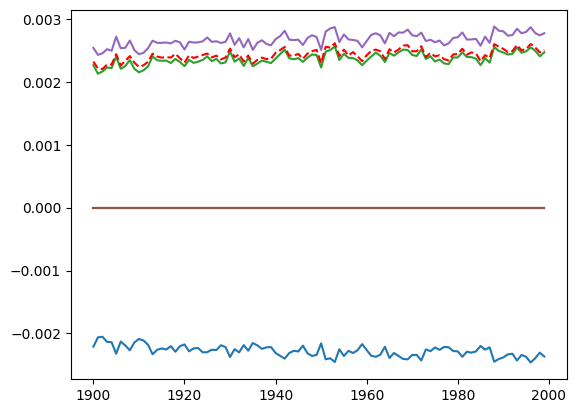

In [355]:
for j in [0,2,5]:
    plt.plot(alt_grad_comps.keys(),alt_grad_comps_numpy[:,j] )
    plt.plot([min(true_grad_comps.keys()),max(true_grad_comps.keys())],[0,0])
plt.plot(alt_grad_comps.keys(),alt_grad_comps_numpy[:,30],"r--" )
plt.show()

    


In [289]:
true_grad_dict[1900]/grad_alt_dict[1900]

array([ 1.47286873e-01,  3.65971745e-01,  8.86065018e-01, -1.18184408e-01,
       -8.37936496e-01, -6.61141286e-02,  3.92097559e+00, -2.40821479e-01,
        2.96811485e-01, -1.56725777e-01,  2.36361726e+00,  3.43529843e-01,
        1.68714365e-01,  1.38507527e-01,  3.77351930e-01, -3.48814485e-01,
        1.77442614e-02, -1.84800302e-01,  1.22764490e-01, -3.98907602e-01,
        7.45984433e-02, -5.27175376e-02,  1.33150843e-01,  8.13393505e-02,
       -1.32787097e+00, -6.79866651e-02,  3.19104910e-01,  7.18939094e-01,
       -1.14393994e+00, -3.04100109e-02, -3.16212068e-02,  1.31558351e-01,
        1.54211577e+00, -2.54805890e-02,  5.34042389e-02, -3.65003337e-01,
       -4.23727056e-01,  1.22197343e-01,  4.35564649e-01, -7.26154815e-03,
        1.14688301e-01,  6.52747516e-02,  1.96091975e-01,  2.30015856e-02,
       -5.16882839e-02,  1.68881573e-01,  3.08151670e-02,  1.17396704e-01,
       -3.86150378e+00,  9.63357072e-03,  7.25945552e-02,  2.37956127e-01,
       -2.06032032e-01,  

In [290]:
true_grad_comps = {}
alt_grad_comps = {}
true_grad_comps_numpy = np.zeros((len(true_grad_dict),31))
alt_grad_comps_numpy = np.zeros((len(grad_alt_dict),31))
for epoch in grad_alt_dict:
    true_grad_comps[epoch] = odt_wts.numpy()@true_grad_dict[epoch]
    true_grad_comps_numpy[epoch-min(true_grad_dict.keys())] = true_grad_comps[epoch]
    alt_grad_comps[epoch] = odt_wts.numpy()@grad_alt_dict[epoch]
    alt_grad_comps_numpy[epoch-min(grad_alt_dict.keys())] = alt_grad_comps[epoch]



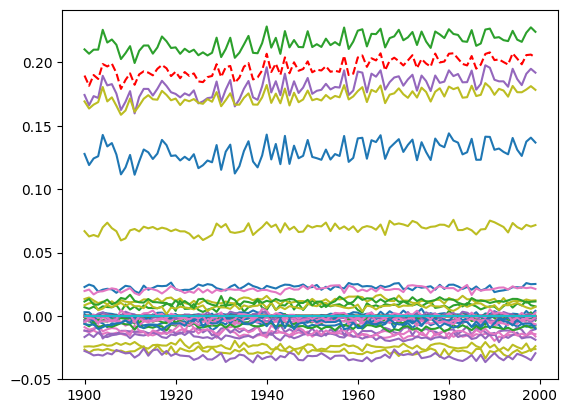

In [299]:

# all paths through node i1 in layer 1
for j in range(30):
    plt.plot(alt_grad_comps.keys(),alt_grad_comps_numpy[:,j] )
    plt.plot([min(true_grad_comps.keys()),max(true_grad_comps.keys())],[0,0])
plt.plot(alt_grad_comps.keys(),alt_grad_comps_numpy[:,30],"r--" )
plt.show()

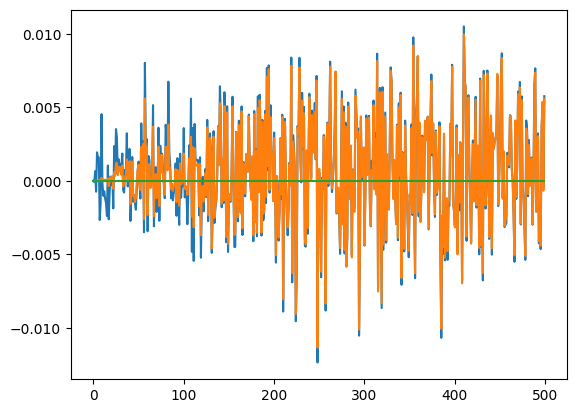

In [108]:
plt.plot(true_grad_comps.keys(),true_grad_comps_numpy[:,0] )
plt.plot(alt_grad_comps.keys(),alt_grad_comps_numpy[:,0] )
plt.plot([min(true_grad_comps.keys()),max(true_grad_comps.keys())],[0,0])

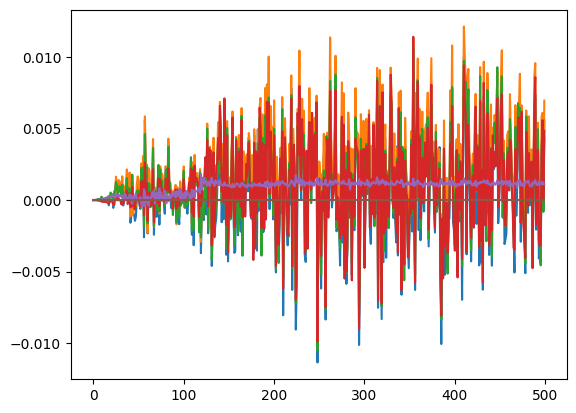

In [97]:
plt.plot(grad_comps.keys(),grad_comps_numpy[:,0])
plt.plot(grad_comps.keys(),grad_comps_numpy[:,2])
plt.plot(grad_comps.keys(),grad_comps_numpy[:,6])
plt.plot(grad_comps.keys(),grad_comps_numpy[:,14])
plt.plot(grad_comps.keys(),grad_comps_numpy[:,30])
plt.plot([min(grad_comps.keys()),max(grad_comps.keys())],[0,0])

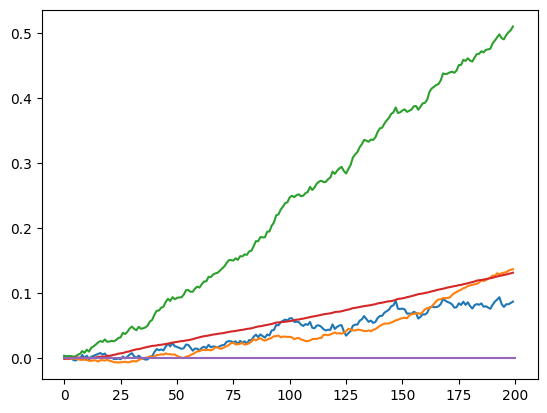

In [65]:
for j in [0,1,2,30]:
    plt.plot(np.cumsum(grad_comps_numpy[100:300,j]))
plt.plot([0,200],[0,0])

In [186]:
W0_comps = {}
W0_comps_numpy = np.zeros((500,31))
for epoch in range(0,500):
    W0_comps[epoch] = odt_wts.numpy()@W0_dict[epoch]
    W0_comps_numpy[epoch] = W0_comps[epoch]


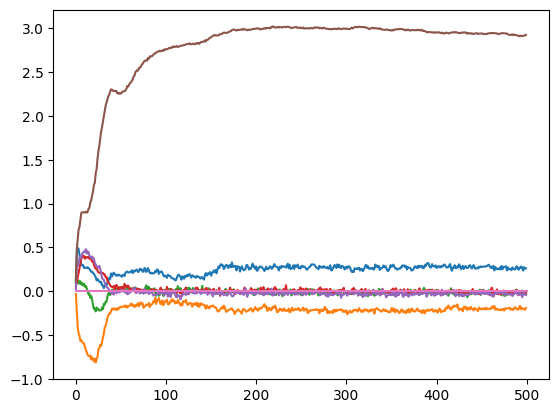

In [188]:

plt.plot(W0_comps.keys(),W0_comps_numpy[:,0])
plt.plot(W0_comps.keys(),W0_comps_numpy[:,2])
plt.plot(W0_comps.keys(),W0_comps_numpy[:,6])
plt.plot(W0_comps.keys(),W0_comps_numpy[:,14])
plt.plot(W0_comps.keys(),W0_comps_numpy[:,30])
plt.plot(W0_comps.keys(),W0_comps_numpy[:,24])
plt.plot([0,500],[0,0])

In [108]:
print(np.max(np.abs(odt_wts.numpy()@grad_alt)))
print(np.argmax(np.abs(odt_wts.numpy()@grad_alt)))
print(odt_wts.numpy()@grad_alt)
print(odt_wts.numpy()@true_grad)

0.004479202994418259
2
[ 3.81081935e-03  2.70010123e-04  4.47920299e-03  2.95804022e-04
  8.86006654e-04 -5.33267421e-04  3.20481095e-03  2.88055942e-04
  5.99186725e-04  3.25973334e-04 -5.64864273e-05  3.22930861e-04
  6.29857492e-04 -8.34030014e-04  2.58873003e-03  7.00441191e-05
  2.92297458e-04  9.32298677e-04 -1.49379927e-05  6.06151467e-05
 -4.09736645e-04 -1.51455845e-04 -3.24845902e-04 -2.13612873e-04
 -3.01012043e-05  1.22585382e-03  2.46137723e-04  2.19183108e-04
 -1.12042957e-03  1.10557638e-03 -9.68425624e-04]
[ 3.8108178e-03  2.7000523e-04  4.4792024e-03  2.9580234e-04
  8.8600430e-04 -5.3326529e-04  3.2048114e-03  2.8805828e-04
  5.9918658e-04  3.2597760e-04 -5.6485311e-05  3.2293270e-04
  6.2985253e-04 -8.3402666e-04  2.5887275e-03  7.0044553e-05
  2.9229585e-04  9.3228830e-04 -1.4938079e-05  6.0613820e-05
 -4.0973868e-04 -1.5145550e-04 -3.2484136e-04 -2.1361304e-04
 -3.0102354e-05  1.2258515e-03  2.4613913e-04  2.1918071e-04
 -1.1204297e-03  1.1055702e-03 -9.6842099e-04

In [92]:
W0[i1]@odt_wts[30]/(torch.norm(W0[i1])*torch.norm(odt_wts[30]))

tensor(-0.8669)

In [108]:
u_ODT_node = seed_result["tree"].w_list[ODT_INTERNAL_NODE_ID]
print("Cosine similarity between grad_alt for neuron i1 and u_ODT_node at epoch", EPOCH, ":", grad_alt@u_ODT_node/(np.linalg.norm(u_ODT_node)*np.linalg.norm(grad_alt)))
print("Norm of grad_alt:", np.linalg.norm(grad_alt))

Cosine similarity between grad_alt for neuron i1 and u_ODT_node at epoch 2 : 0.24897442004383827
Norm of grad_alt: 0.002980160197043697


In [ ]:
from layer_lenses.relu_analysis import summarize_neuron_leaf_activity

checkpoint_model = checkpoint_model_from_state(seed_result["out"]["model"], ckpts[EPOCH])

neuron_leaf_activity_summary = summarize_neuron_leaf_activity(
    model=checkpoint_model,
    x_eval=seed_result["data"]["x_eval"],
    tree=seed_result["tree"],
)

# display(neuron_leaf_activity_summary)
# show(
#     neuron_leaf_activity_summary,
#     scrollY="500px",
#     scrollX=True,
#     search=True,
#     paging=True,
#     pageLength=25,
# )

In [ ]:
# Build: neuron -> activity vector over ODT leaves
# Input: neuron_leaf_activity_summary (DataFrame from earlier cell)
# Output: neuron_to_leaf_activity (dict)

from layer_lenses.relu_analysis import neuron_leaf_activity_dict

neuron_to_leaf_activity, neuron_activity_leaf_order = neuron_leaf_activity_dict(
    neuron_leaf_activity_summary,
    key_mode="layer_local",
)

print(f"Built dictionary for {len(neuron_to_leaf_activity)} neurons.")
print(f"Vector length per neuron: {len(neuron_activity_leaf_order)} leaves")
print("Example key:", next(iter(neuron_to_leaf_activity)))
print("Example vector:", neuron_to_leaf_activity[next(iter(neuron_to_leaf_activity))])

In [ ]:
neuron_to_leaf_activity[(1,7)]

## Start/end metrics

This block computes start/end metrics for the selected seed.

In [16]:
if seed_result is None:
    raise ValueError("Run the training cell first to populate seed_result.")

rows = collect_start_end_metrics(seed_result)
metrics_table = pd.DataFrame(rows).sort_values(["timepoint"]).reset_index(drop=True)
display(metrics_table)

,timepoint,epoch,train_log_loss,test_error
0,end,1999,0.054855,0.179312
1,start,0,0.693175,0.500475


## Quick visualization

Bar plots for start vs end test error and train log loss for the selected seed.

In [ ]:
if seed_result is None:
    raise ValueError("Run the training cell first to populate seed_result.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(metrics_table["timepoint"], metrics_table["test_error"])
axes[0].set_title("Test error")

axes[1].bar(metrics_table["timepoint"], metrics_table["train_log_loss"])
axes[1].set_title("Train log loss")

plt.tight_layout()
plt.show()